# 🧠 Stress Detection — Model Comparison
### Comparing CNN vs MobileNetV2 vs SVM
**Goal:** Train all 3 models, compare accuracy, save the best model as `model.h5`

## 📦 Step 1: Mount Google Drive & Extract Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

with zipfile.ZipFile('/content/drive/MyDrive/train.zip', 'r') as z:
    z.extractall('.')
with zipfile.ZipFile('/content/drive/MyDrive/test.zip', 'r') as z:
    z.extractall('.')

print('✅ Files extracted!')
print('Train folders:', os.listdir('train'))
print('Test folders:' , os.listdir('test'))

Mounted at /content/drive
✅ Files extracted!
Train folders: ['neutral', 'sad', 'angry', 'happy', 'fearful', 'disgusted', 'surprised']
Test folders: ['neutral', 'sad', 'angry', 'happy', 'fearful', 'disgusted', 'surprised']


## 📊 Step 2: Load & Preprocess Data (Common for all models)

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ──
IMG_SIZE    = 48
CLASSES     = ['angry','disgusted','fearful','happy','neutral','sad','surprised']
STRESS_LABELS = ['angry','disgusted','fearful','sad']   # → label 1
TRAIN_DIR   = 'train'
TEST_DIR    = 'test'

# ── Load images ──
def load_images(directory):
    images, emotion_labels, stress_labels = [], [], []
    for idx, cls in enumerate(CLASSES):
        folder = os.path.join(directory, cls)
        if not os.path.exists(folder):
            print(f'⚠️  Folder not found: {folder}')
            continue
        files = os.listdir(folder)
        print(f'  {cls}: {len(files)} images')
        for fname in files:
            fpath = os.path.join(folder, fname)
            img   = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.equalizeHist(img)   # normalize brightness
            images.append(img)
            emotion_labels.append(idx)
            stress_labels.append(1 if cls in STRESS_LABELS else 0)
    return np.array(images), np.array(emotion_labels), np.array(stress_labels)

print('Loading train data...')
X_train_raw, y_train_emo, y_train_stress = load_images(TRAIN_DIR)
print(f'Train: {X_train_raw.shape}')

print('\nLoading test data...')
X_test_raw, y_test_emo, y_test_stress = load_images(TEST_DIR)
print(f'Test: {X_test_raw.shape}')

Loading train data...
  angry: 3995 images
  disgusted: 436 images
  fearful: 4097 images
  happy: 7215 images
  neutral: 4965 images
  sad: 4830 images
  surprised: 3171 images
Train: (28709, 48, 48)

Loading test data...
  angry: 958 images
  disgusted: 111 images
  fearful: 1024 images
  happy: 1774 images
  neutral: 1233 images
  sad: 1247 images
  surprised: 831 images
Test: (7178, 48, 48)


✅ Data prepared
   CNN  shape : (28709, 48, 48, 1)
   SVM  shape : (28709, 2304)


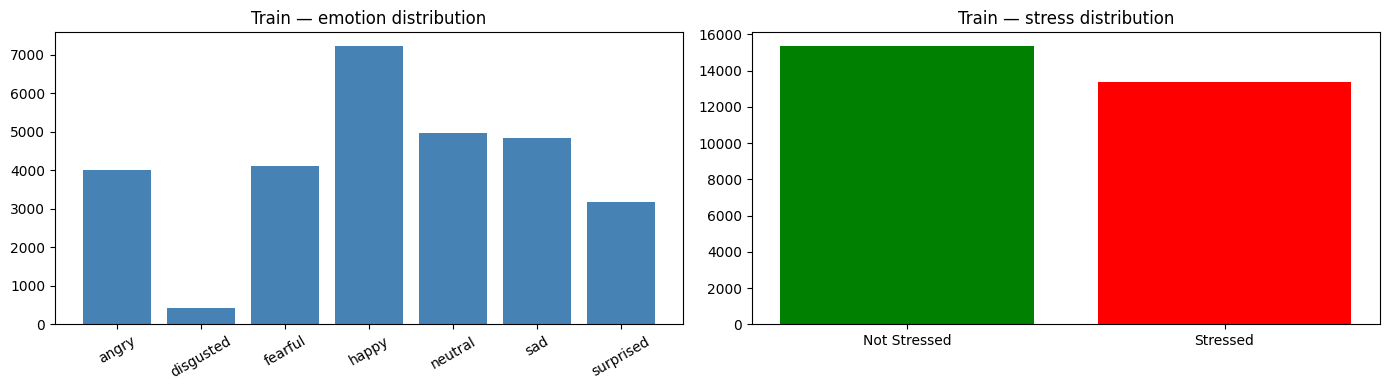

In [ ]:
from tensorflow.keras.utils import to_categorical

# ── For CNN / MobileNetV2 : shape (N, 48, 48, 1), normalized ──
X_train_cnn = (X_train_raw.astype('float32') / 255.0)[..., np.newaxis]
X_test_cnn  = (X_test_raw .astype('float32') / 255.0)[..., np.newaxis]

# One-hot for 7-class emotion
y_train_cat = to_categorical(y_train_emo, 7)
y_test_cat  = to_categorical(y_test_emo,  7)

# ── For SVM : flatten to 1-D ──
X_train_flat = X_train_raw.reshape(len(X_train_raw), -1).astype('float32') / 255.0
X_test_flat  = X_test_raw .reshape(len(X_test_raw),  -1).astype('float32') / 255.0

print('✅ Data prepared')
print(f'   CNN  shape : {X_train_cnn.shape}')
print(f'   SVM  shape : {X_train_flat.shape}')

# ── Quick class-distribution plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
counts = [np.sum(y_train_emo == i) for i in range(7)]
axes[0].bar(CLASSES, counts, color='steelblue')
axes[0].set_title('Train — emotion distribution')
axes[0].tick_params(axis='x', rotation=30)
axes[1].bar(['Not Stressed', 'Stressed'],
            [np.sum(y_train_stress==0), np.sum(y_train_stress==1)],
            color=['green','red'])
axes[1].set_title('Train — stress distribution')
plt.tight_layout(); plt.show()

---
## 🤖 Model 1 — Custom CNN  *(your original model)*

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_cnn():
    m = Sequential([
        Conv2D(32,  (3,3), activation='relu', input_shape=(48,48,1)),
        BatchNormalization(),
        Conv2D(64,  (3,3), activation='relu'),
        MaxPooling2D(2,2), Dropout(0.25),

        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2), Dropout(0.25),

        Flatten(),
        Dense(1024, activation='relu'), Dropout(0.5),
        Dense(7,    activation='softmax')
    ])
    m.compile(optimizer=Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

cnn_model = build_cnn()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    10,617,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,865,927 (41.45 MB)

 Trainable params: 10,865,607 (41.45 MB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_test_cnn, y_test_cat),
    epochs=50, batch_size=64,
    callbacks=callbacks, verbose=1
)

# ── Evaluate ──
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn, verbose=0), axis=1)

# Stress-level accuracy
y_pred_cnn_stress = np.array([1 if CLASSES[p] in STRESS_LABELS else 0 for p in y_pred_cnn])
cnn_stress_acc = accuracy_score(y_test_stress, y_pred_cnn_stress)

print(f'\n✅ CNN  |  Emotion acc: {cnn_acc:.4f}  |  Stress acc: {cnn_stress_acc:.4f}')

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 742s 2s/step - accuracy: 0.2863 - loss: 1.8443 - val_accuracy: 0.3299 - val_loss: 1.7027 - learning_rate: 1.0000e-04
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 746s 2s/step - accuracy: 0.3655 - loss: 1.6106 - val_accuracy: 0.4361 - val_loss: 1.4908 - learning_rate: 1.0000e-04
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 740s 2s/step - accuracy: 0.4157 - loss: 1.5099 - val_accuracy: 0.4553 - val_loss: 1.4057 - learning_rate: 1.0000e-04
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 757s 2s/step - accuracy: 0.4417 - loss: 1.4443 - val_accuracy: 0.4671 - val_loss: 1.3670 - learning_rate: 1.0000e-04
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 741s 2s/step - accuracy: 0.4601 - loss: 1.3924 - val_accuracy: 0.4838 - val_loss: 1.3211 - learning_rate: 1.0000e-04
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 749s 2s/step - accuracy: 0.4823 - loss: 1.3516 - val_accuracy: 0.5008 - val_loss: 1.2863 - learning_rate: 1.0000e-04
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 799s 2s/step - acc

In [ ]:
# ── Training curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cnn_history.history['accuracy'],     label='train')
axes[0].plot(cnn_history.history['val_accuracy'], label='val')
axes[0].set_title('CNN — Accuracy'); axes[0].legend()
axes[1].plot(cnn_history.history['loss'],     label='train')
axes[1].plot(cnn_history.history['val_loss'], label='val')
axes[1].set_title('CNN — Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

# ── Confusion matrix ──
cm = confusion_matrix(y_test_emo, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('CNN — Confusion Matrix'); plt.tight_layout(); plt.show()
print(classification_report(y_test_emo, y_pred_cnn, target_names=CLASSES))

---
## 🤖 Model 2 — MobileNetV2 (Transfer Learning)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Input
import tensorflow as tf

# MobileNetV2 needs 3-channel input — convert grayscale → RGB by repeating channel
X_train_rgb = np.repeat(X_train_cnn, 3, axis=-1)
X_test_rgb  = np.repeat(X_test_cnn,  3, axis=-1)
print('RGB shape:', X_train_rgb.shape)

def build_mobilenet():
    base = MobileNetV2(input_shape=(48,48,3),
                       include_top=False,
                       weights='imagenet')
    # Freeze base first, then fine-tune
    base.trainable = False

    inp = Input(shape=(48,48,3))
    x   = base(inp, training=False)
    x   = GlobalAveragePooling2D()(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.4)(x)
    out = Dense(7, activation='softmax')(x)

    m = Model(inp, out)
    m.compile(optimizer=Adam(1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m, base

mob_model, mob_base = build_mobilenet()
mob_model.summary()

In [ ]:
callbacks2 = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

# Phase 1 — train head only
print('=== Phase 1: Training head only ===')
mob_history1 = mob_model.fit(
    X_train_rgb, y_train_cat,
    validation_data=(X_test_rgb, y_test_cat),
    epochs=15, batch_size=64,
    callbacks=callbacks2, verbose=1
)

# Phase 2 — unfreeze top 30 layers and fine-tune
print('\n=== Phase 2: Fine-tuning top layers ===')
mob_base.trainable = True
for layer in mob_base.layers[:-30]:
    layer.trainable = False

mob_model.compile(optimizer=Adam(1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

mob_history2 = mob_model.fit(
    X_train_rgb, y_train_cat,
    validation_data=(X_test_rgb, y_test_cat),
    epochs=20, batch_size=32,
    callbacks=callbacks2, verbose=1
)

# ── Evaluate ──
mob_loss, mob_acc = mob_model.evaluate(X_test_rgb, y_test_cat, verbose=0)
y_pred_mob = np.argmax(mob_model.predict(X_test_rgb, verbose=0), axis=1)
y_pred_mob_stress = np.array([1 if CLASSES[p] in STRESS_LABELS else 0 for p in y_pred_mob])
mob_stress_acc = accuracy_score(y_test_stress, y_pred_mob_stress)

print(f'\n✅ MobileNetV2  |  Emotion acc: {mob_acc:.4f}  |  Stress acc: {mob_stress_acc:.4f}')

In [ ]:
# ── Confusion matrix ──
cm2 = confusion_matrix(y_test_emo, y_pred_mob)
plt.figure(figsize=(8,6))
sns.heatmap(cm2, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Oranges')
plt.title('MobileNetV2 — Confusion Matrix'); plt.tight_layout(); plt.show()
print(classification_report(y_test_emo, y_pred_mob, target_names=CLASSES))

---
## 🤖 Model 3 — SVM with HOG Features

In [ ]:
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# ── Extract HOG features ──
def extract_hog(images):
    features = []
    for img in images:
        # img is (48,48) uint8
        fd = hog(img.squeeze() if img.ndim==3 else img,
                 orientations=9,
                 pixels_per_cell=(8,8),
                 cells_per_block=(2,2),
                 block_norm='L2-Hys')
        features.append(fd)
    return np.array(features)

print('Extracting HOG features...')
X_train_hog = extract_hog(X_train_raw)
X_test_hog  = extract_hog(X_test_raw)
print(f'HOG feature shape: {X_train_hog.shape}')

In [ ]:
# ── Train SVM ──
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale',
                   decision_function_shape='ovr', verbose=True))
])

print('Training SVM (this may take a few minutes)...')
svm_pipeline.fit(X_train_hog, y_train_emo)

# ── Evaluate ──
y_pred_svm = svm_pipeline.predict(X_test_hog)
svm_acc    = accuracy_score(y_test_emo, y_pred_svm)
y_pred_svm_stress = np.array([1 if CLASSES[p] in STRESS_LABELS else 0 for p in y_pred_svm])
svm_stress_acc = accuracy_score(y_test_stress, y_pred_svm_stress)

print(f'\n✅ SVM  |  Emotion acc: {svm_acc:.4f}  |  Stress acc: {svm_stress_acc:.4f}')

In [ ]:
cm3 = confusion_matrix(y_test_emo, y_pred_svm)
plt.figure(figsize=(8,6))
sns.heatmap(cm3, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Greens')
plt.title('SVM — Confusion Matrix'); plt.tight_layout(); plt.show()
print(classification_report(y_test_emo, y_pred_svm, target_names=CLASSES))

---
## 📊 Step 3 — Compare All 3 Models

In [ ]:
results = {
    'Custom CNN':   {'emotion_acc': cnn_acc,  'stress_acc': cnn_stress_acc},
    'MobileNetV2':  {'emotion_acc': mob_acc,  'stress_acc': mob_stress_acc},
    'SVM + HOG':    {'emotion_acc': svm_acc,  'stress_acc': svm_stress_acc},
}

# ── Print comparison table ──
print('='*55)
print(f'{"Model":<18} {"Emotion Acc":>14} {"Stress Acc":>14}')
print('-'*55)
for name, r in results.items():
    print(f'{name:<18} {r["emotion_acc"]:>13.2%} {r["stress_acc"]:>13.2%}')
print('='*55)

# ── Bar chart comparison ──
models     = list(results.keys())
emo_accs   = [r['emotion_acc']  for r in results.values()]
stress_accs= [r['stress_acc']   for r in results.values()]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, emo_accs,    width, label='Emotion Accuracy', color='steelblue')
b2 = ax.bar(x + width/2, stress_accs, width, label='Stress Accuracy',  color='tomato')

ax.set_xticks(x); ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy'); ax.set_title('Model Comparison — Emotion vs Stress Accuracy')
ax.legend()

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.annotate(f'{h:.2%}', xy=(bar.get_x()+bar.get_width()/2, h),
                xytext=(0,4), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout(); plt.show()

---
## 💾 Step 4 — Save the Best Model as `model.h5`

In [ ]:
# ── Find best model by stress accuracy (most important for this project) ──
best_name = max(results, key=lambda k: results[k]['stress_acc'])
print(f'🏆 Best model: {best_name}')
print(f'   Emotion accuracy : {results[best_name]["emotion_acc"]:.2%}')
print(f'   Stress  accuracy : {results[best_name]["stress_acc"]:.2%}')

SAVE_PATH = '/content/drive/MyDrive/model.h5'

if best_name == 'Custom CNN':
    cnn_model.save(SAVE_PATH)
    print(f'✅ CNN model saved to {SAVE_PATH}')

elif best_name == 'MobileNetV2':
    mob_model.save(SAVE_PATH)
    print(f'✅ MobileNetV2 model saved to {SAVE_PATH}')
    print('⚠️  NOTE: MobileNetV2 needs 3-channel input.')
    print('   Update views.py: arr = np.repeat(arr, 3, axis=-1)')

elif best_name == 'SVM + HOG':
    # Save SVM separately (not h5, but pkl)
    import joblib
    svm_path = '/content/drive/MyDrive/svm_model.pkl'
    joblib.dump(svm_pipeline, svm_path)
    print(f'✅ SVM model saved to {svm_path}')
    print('⚠️  NOTE: SVM is saved as .pkl not .h5')
    print('   You need to update views.py to use joblib.load() instead of keras')

print('\n✅ Done! Download the model from Google Drive and replace your model.h5')

---
## 📋 Summary

| Model | Type | Pros | Cons |
|---|---|---|---|
| **Custom CNN** | Deep Learning | Fast, lightweight, trained on grayscale | Needs large data |
| **MobileNetV2** | Transfer Learning | High accuracy, pretrained on ImageNet | Needs RGB input, heavier |
| **SVM + HOG** | Classical ML | Works with less data, interpretable | Slower, lower accuracy on complex faces |

### After downloading best model:
1. Replace `model.h5` in your Django project folder
2. Restart server: `python manage.py runserver`
